# MIMIC-IV 30-Day Readmission Prediction
## Notebook 2: Feature Engineering

This notebook builds the feature matrix for modeling by engineering features
from all four MIMIC-IV tables. Features are grouped into:
1. Demographic features (age, gender)
2. Admission features (length of stay, admission type, discharge location)
3. Comorbidity features (Elixhauser index from diagnosis codes)
4. Medication features (prescription counts and drug classes)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_DIR = Path('../data')
FIGURES_DIR = Path('../figures')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
print("Loading data...")

# Load base cohort from notebook 1
cohort = pd.read_csv(DATA_DIR / 'cohort_base.csv', parse_dates=['admittime', 'dischtime'])
print(f"Base cohort: {cohort.shape}")

# Load supporting tables
patients = pd.read_csv(DATA_DIR / 'patients.csv.gz')
diagnoses = pd.read_csv(DATA_DIR / 'diagnoses_icd.csv.gz')
prescriptions = pd.read_csv(DATA_DIR / 'prescriptions.csv.gz')

print(f"Patients: {patients.shape}")
print(f"Diagnoses: {diagnoses.shape}")
print(f"Prescriptions: {prescriptions.shape}")
print("\nAll tables loaded successfully")

Loading data...
Base cohort: (534227, 19)
Patients: (364627, 6)
Diagnoses: (6364488, 5)
Prescriptions: (20292611, 21)

All tables loaded successfully


In [3]:
print("=== DEMOGRAPHIC FEATURES ===")

# Merge patients table into cohort
cohort = cohort.merge(
    patients[['subject_id', 'gender', 'anchor_age', 'anchor_year', 'dod']],
    on='subject_id',
    how='left'
)

# Calculate age at admission
# MIMIC uses anchor_age and anchor_year for de-identification
# Age at admission = anchor_age + (admission year - anchor_year)
cohort['admission_year'] = cohort['admittime'].dt.year
cohort['age_at_admission'] = (
    cohort['anchor_age'] + 
    (cohort['admission_year'] - cohort['anchor_year'])
)

# Encode gender as binary
cohort['gender_binary'] = (cohort['gender'] == 'M').astype(int)

print(f"Age at admission stats:")
print(cohort['age_at_admission'].describe())
print(f"\nGender distribution:")
print(cohort['gender'].value_counts())

# Filter to adults only (age >= 18)
before = len(cohort)
cohort = cohort[cohort['age_at_admission'] >= 18].copy()
print(f"\nRemoved {before - len(cohort):,} pediatric admissions")
print(f"Remaining admissions: {len(cohort):,}")

=== DEMOGRAPHIC FEATURES ===
Age at admission stats:
count   534227.00
mean        58.89
std         19.14
min         18.00
25%         45.00
50%         61.00
75%         74.00
max        106.00
Name: age_at_admission, dtype: float64

Gender distribution:
gender
F    278695
M    255532
Name: count, dtype: int64

Removed 0 pediatric admissions
Remaining admissions: 534,227


In [4]:
print("=== ADMISSION FEATURES ===")

# Length of stay in days
cohort['los_days'] = (
    cohort['dischtime'] - cohort['admittime']
).dt.total_seconds() / (24 * 3600)

print(f"Length of stay stats:")
print(cohort['los_days'].describe())

# Admission hour (captures time of day patterns)
cohort['admit_hour'] = cohort['admittime'].dt.hour

# Admission day of week (0=Monday, 6=Sunday)
cohort['admit_dow'] = cohort['admittime'].dt.dayofweek

# Weekend admission flag
cohort['weekend_admission'] = (cohort['admit_dow'] >= 5).astype(int)

print(f"\nWeekend admissions: {cohort['weekend_admission'].mean():.1%}")
print(f"\nAdmission type distribution:")
print(cohort['admission_type'].value_counts())
print(f"\nDischarge location distribution:")
print(cohort['discharge_location'].value_counts())

=== ADMISSION FEATURES ===
Length of stay stats:
count   534227.00
mean         4.65
std          6.93
min         -0.80
25%          1.12
50%          2.80
75%          5.52
max        515.56
Name: los_days, dtype: float64

Weekend admissions: 28.9%

Admission type distribution:
admission_type
EW EMER.                       170809
EU OBSERVATION                 119346
OBSERVATION ADMIT               82598
URGENT                          52484
SURGICAL SAME DAY ADMISSION     42750
DIRECT OBSERVATION              24521
DIRECT EMER.                    21489
ELECTIVE                        13036
AMBULATORY OBSERVATION           7194
Name: count, dtype: int64

Discharge location distribution:
discharge_location
HOME                            194116
HOME HEALTH CARE                 99296
SKILLED NURSING FACILITY         52642
REHAB                            13842
CHRONIC/LONG TERM ACUTE CARE      8121
HOSPICE                           5375
AGAINST ADVICE                    3393
PSYCH FACI

In [5]:
print("=== ENCODING CATEGORICAL FEATURES ===")

# One-hot encode admission type
admission_type_dummies = pd.get_dummies(
    cohort['admission_type'], 
    prefix='admtype',
    drop_first=True
)

# One-hot encode discharge location
discharge_dummies = pd.get_dummies(
    cohort['discharge_location'],
    prefix='discloc',
    drop_first=True
)

# One-hot encode insurance
insurance_dummies = pd.get_dummies(
    cohort['insurance'],
    prefix='insurance',
    drop_first=True
)

# One-hot encode marital status
marital_dummies = pd.get_dummies(
    cohort['marital_status'],
    prefix='marital',
    drop_first=True
)

# Concatenate all dummies to cohort
cohort = pd.concat([
    cohort,
    admission_type_dummies,
    discharge_dummies,
    insurance_dummies,
    marital_dummies
], axis=1)

print(f"Added {len(admission_type_dummies.columns)} admission type features")
print(f"Added {len(discharge_dummies.columns)} discharge location features")
print(f"Added {len(insurance_dummies.columns)} insurance features")
print(f"Added {len(marital_dummies.columns)} marital status features")
print(f"\nCurrent cohort shape: {cohort.shape}")

=== ENCODING CATEGORICAL FEATURES ===
Added 8 admission type features
Added 12 discharge location features
Added 4 insurance features
Added 3 marital status features

Current cohort shape: (534227, 57)


In [6]:
print("=== COMORBIDITY FEATURES ===")

# Filter diagnoses to our cohort admissions only
cohort_hadm_ids = set(cohort['hadm_id'])
diagnoses_cohort = diagnoses[diagnoses['hadm_id'].isin(cohort_hadm_ids)].copy()
print(f"Diagnoses for cohort admissions: {len(diagnoses_cohort):,}")

# Total number of diagnoses per admission (proxy for complexity)
diag_count = (diagnoses_cohort.groupby('hadm_id')['icd_code']
              .count()
              .reset_index()
              .rename(columns={'icd_code': 'n_diagnoses'}))

cohort = cohort.merge(diag_count, on='hadm_id', how='left')
cohort['n_diagnoses'] = cohort['n_diagnoses'].fillna(0)

print(f"\nDiagnoses per admission stats:")
print(cohort['n_diagnoses'].describe())

# Primary diagnosis (seq_num == 1)
primary_diag = (diagnoses_cohort[diagnoses_cohort['seq_num'] == 1]
                [['hadm_id', 'icd_code', 'icd_version']]
                .rename(columns={
                    'icd_code': 'primary_icd_code',
                    'icd_version': 'primary_icd_version'
                }))

cohort = cohort.merge(primary_diag, on='hadm_id', how='left')
print(f"\nMissing primary diagnosis: {cohort['primary_icd_code'].isnull().sum()}")

=== COMORBIDITY FEATURES ===
Diagnoses for cohort admissions: 6,102,067

Diagnoses per admission stats:
count   534227.00
mean        11.42
std          7.42
min          0.00
25%          6.00
50%         10.00
75%         16.00
max         57.00
Name: n_diagnoses, dtype: float64

Missing primary diagnosis: 522


In [7]:
print("=== HIGH RISK CONDITION FLAGS ===")

# Define ICD code prefixes for high-risk conditions
# These are well-established readmission risk factors in literature
high_risk_conditions = {
    'heart_failure': {
        'icd9': ['428'],
        'icd10': ['I50']
    },
    'renal_failure': {
        'icd9': ['584', '585', '586'],
        'icd10': ['N17', 'N18', 'N19']
    },
    'diabetes': {
        'icd9': ['250'],
        'icd10': ['E10', 'E11', 'E12', 'E13', 'E14']
    },
    'copd': {
        'icd9': ['491', '492', '496'],
        'icd10': ['J44']
    },
    'pneumonia': {
        'icd9': ['486'],
        'icd10': ['J18']
    },
    'sepsis': {
        'icd9': ['038', '995'],
        'icd10': ['A40', 'A41']
    }
}

def has_condition(hadm_diagnoses, icd9_prefixes, icd10_prefixes):
    """Check if any diagnosis code matches the condition prefixes"""
    icd9_codes = hadm_diagnoses[hadm_diagnoses['icd_version'] == 9]['icd_code']
    icd10_codes = hadm_diagnoses[hadm_diagnoses['icd_version'] == 10]['icd_code']
    
    has_icd9 = any(
        str(code).startswith(tuple(icd9_prefixes)) 
        for code in icd9_codes
    )
    has_icd10 = any(
        str(code).startswith(tuple(icd10_prefixes)) 
        for code in icd10_codes
    )
    return int(has_icd9 or has_icd10)

# Create condition flags for each admission
print("Computing condition flags (this may take a minute)...")

for condition, prefixes in high_risk_conditions.items():
    flags = (diagnoses_cohort.groupby('hadm_id')
             .apply(lambda x: has_condition(
                 x, 
                 prefixes['icd9'], 
                 prefixes['icd10']
             ))
             .reset_index()
             .rename(columns={0: f'has_{condition}'}))
    
    cohort = cohort.merge(flags, on='hadm_id', how='left')
    cohort[f'has_{condition}'] = cohort[f'has_{condition}'].fillna(0).astype(int)
    prevalence = cohort[f'has_{condition}'].mean()
    print(f"has_{condition}: {prevalence:.1%} prevalence")

=== HIGH RISK CONDITION FLAGS ===
Computing condition flags (this may take a minute)...
has_heart_failure: 14.3% prevalence
has_renal_failure: 22.0% prevalence
has_diabetes: 24.2% prevalence
has_copd: 7.5% prevalence
has_pneumonia: 3.6% prevalence
has_sepsis: 3.6% prevalence


In [8]:
print("=== PRESCRIPTION FEATURES ===")

# Filter prescriptions to cohort admissions
prescriptions_cohort = prescriptions[
    prescriptions['hadm_id'].isin(cohort_hadm_ids)
].copy()
print(f"Prescriptions for cohort: {len(prescriptions_cohort):,}")

# Total number of unique medications per admission
med_count = (prescriptions_cohort.groupby('hadm_id')['drug']
             .nunique()
             .reset_index()
             .rename(columns={'drug': 'n_medications'}))

cohort = cohort.merge(med_count, on='hadm_id', how='left')
cohort['n_medications'] = cohort['n_medications'].fillna(0)

print(f"\nMedications per admission stats:")
print(cohort['n_medications'].describe())

# High risk medication flags
high_risk_meds = {
    'has_insulin': ['insulin'],
    'has_anticoagulant': ['warfarin', 'heparin', 'enoxaparin', 
                          'apixaban', 'rivaroxaban'],
    'has_opioid': ['morphine', 'oxycodone', 'hydrocodone', 
                   'fentanyl', 'hydromorphone'],
    'has_diuretic': ['furosemide', 'torsemide', 'bumetanide',
                     'spironolactone']
}

for flag_name, drug_list in high_risk_meds.items():
    pattern = '|'.join(drug_list)
    flags = (prescriptions_cohort[
        prescriptions_cohort['drug'].str.lower().str.contains(
            pattern, na=False
        )
    ]
    .groupby('hadm_id')['drug']
    .count()
    .reset_index()
    .rename(columns={'drug': flag_name}))
    
    flags[flag_name] = 1  # Convert to binary flag
    cohort = cohort.merge(flags, on='hadm_id', how='left')
    cohort[flag_name] = cohort[flag_name].fillna(0).astype(int)
    print(f"{flag_name}: {cohort[flag_name].mean():.1%} of admissions")

=== PRESCRIPTION FEATURES ===
Prescriptions for cohort: 18,893,114

Medications per admission stats:
count   534236.00
mean        19.83
std         15.39
min          0.00
25%         11.00
50%         18.00
75%         27.00
max        196.00
Name: n_medications, dtype: float64
has_insulin: 26.5% of admissions
has_anticoagulant: 65.5% of admissions
has_opioid: 48.3% of admissions
has_diuretic: 20.9% of admissions


In [9]:
print("=== BUILDING FINAL FEATURE MATRIX ===")

# Define which columns are features vs metadata
metadata_cols = [
    'subject_id', 'hadm_id', 'admittime', 'dischtime', 
    'deathtime', 'edregtime', 'edouttime', 'next_admittime',
    'days_to_readmission', 'admission_year', 'anchor_age',
    'anchor_year', 'dod', 'admit_provider_id', 'gender',
    'admission_type', 'discharge_location', 'insurance',
    'marital_status', 'race', 'language',
    'primary_icd_code', 'primary_icd_version'
]

target_col = 'readmitted_30'

# Feature columns are everything else
feature_cols = [
    col for col in cohort.columns 
    if col not in metadata_cols 
    and col != target_col
    and cohort[col].dtype in ['int64', 'float64', 'int32', 'bool']
]

print(f"Number of features: {len(feature_cols)}")
print(f"\nFeature list:")
for f in feature_cols:
    print(f"  {f}")

=== BUILDING FINAL FEATURE MATRIX ===
Number of features: 46

Feature list:
  hospital_expire_flag
  age_at_admission
  gender_binary
  los_days
  admit_hour
  admit_dow
  weekend_admission
  admtype_DIRECT EMER.
  admtype_DIRECT OBSERVATION
  admtype_ELECTIVE
  admtype_EU OBSERVATION
  admtype_EW EMER.
  admtype_OBSERVATION ADMIT
  admtype_SURGICAL SAME DAY ADMISSION
  admtype_URGENT
  discloc_AGAINST ADVICE
  discloc_ASSISTED LIVING
  discloc_CHRONIC/LONG TERM ACUTE CARE
  discloc_DIED
  discloc_HEALTHCARE FACILITY
  discloc_HOME
  discloc_HOME HEALTH CARE
  discloc_HOSPICE
  discloc_OTHER FACILITY
  discloc_PSYCH FACILITY
  discloc_REHAB
  discloc_SKILLED NURSING FACILITY
  insurance_Medicare
  insurance_No charge
  insurance_Other
  insurance_Private
  marital_MARRIED
  marital_SINGLE
  marital_WIDOWED
  n_diagnoses
  has_heart_failure
  has_renal_failure
  has_diabetes
  has_copd
  has_pneumonia
  has_sepsis
  n_medications
  has_insulin
  has_anticoagulant
  has_opioid
  has_diur

In [10]:
print("=== MISSING VALUE CHECK ===")

feature_matrix = cohort[feature_cols + [target_col]].copy()

missing = feature_matrix.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print("Features with missing values:")
    print(missing)
    print("\nFilling missing values with 0...")
    feature_matrix = feature_matrix.fillna(0)
else:
    print("No missing values found")

print(f"\nFinal feature matrix shape: {feature_matrix.shape}")
print(f"Target distribution:")
print(feature_matrix[target_col].value_counts())
print(f"Readmission rate: {feature_matrix[target_col].mean():.1%}")

=== MISSING VALUE CHECK ===
No missing values found

Final feature matrix shape: (534236, 47)
Target distribution:
readmitted_30
0    441470
1     92766
Name: count, dtype: int64
Readmission rate: 17.4%


=== FEATURE CORRELATIONS WITH TARGET ===
Top 20 features correlated with readmission:
n_diagnoses                0.12
n_medications              0.12
has_anticoagulant          0.09
has_renal_failure          0.08
discloc_HOME HEALTH CARE   0.08
has_diuretic               0.08
los_days                   0.07
admtype_DIRECT EMER.       0.07
admtype_EU OBSERVATION     0.07
has_insulin                0.06
has_heart_failure          0.06
has_diabetes               0.05
admtype_ELECTIVE           0.05
insurance_Private          0.05
has_opioid                 0.04
age_at_admission           0.04
insurance_Medicare         0.04
discloc_HOSPICE            0.04
gender_binary              0.03
admtype_URGENT             0.03
Name: readmitted_30, dtype: float64


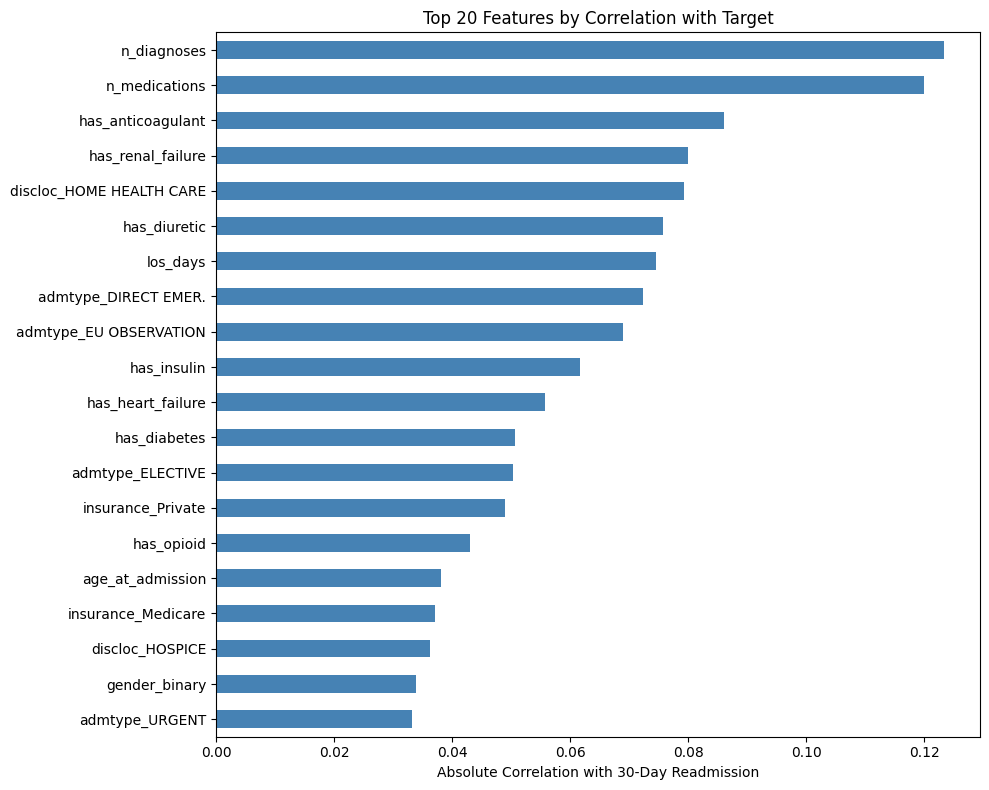

In [11]:
print("=== FEATURE CORRELATIONS WITH TARGET ===")

correlations = (feature_matrix.corr()[target_col]
                .drop(target_col)
                .abs()
                .sort_values(ascending=False))

print("Top 20 features correlated with readmission:")
print(correlations.head(20))

plt.figure(figsize=(10, 8))
correlations.head(20).sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Absolute Correlation with 30-Day Readmission')
plt.title('Top 20 Features by Correlation with Target')
plt.tight_layout()
plt.savefig('../figures/feature_correlations.png', dpi=150)
plt.show()

In [12]:
# Step 1 - Remove negative LOS
neg_los = feature_matrix['los_days'] < 0
print(f"Removing {neg_los.sum()} negative LOS rows")
feature_matrix = feature_matrix[~neg_los].copy()

# Step 2 - Remove extreme LOS
extreme_los = feature_matrix['los_days'] > 365
print(f"Removing {extreme_los.sum()} extreme LOS rows")
feature_matrix = feature_matrix[~extreme_los].copy()

# Step 3 - Remove hospital_expire_flag
if 'hospital_expire_flag' in feature_matrix.columns:
    feature_matrix = feature_matrix.drop('hospital_expire_flag', axis=1)
    print("Removed hospital_expire_flag")

# Step 4 - Add hadm_id from filtered cohort
cohort_filtered = cohort[
    (cohort['los_days'] >= 0) & 
    (cohort['los_days'] <= 365)
].reset_index(drop=True)

feature_matrix['hadm_id'] = cohort_filtered['hadm_id'].values

# Step 5 - Remove duplicates
feature_matrix = feature_matrix.drop_duplicates(
    subset='hadm_id', keep='first'
).reset_index(drop=True)

# Step 6 - Verify
print(f"\nFinal shape: {feature_matrix.shape}")
print(f"Unique hadm_ids: {feature_matrix['hadm_id'].nunique():,}")
print(f"Rows == unique hadm_ids: {len(feature_matrix) == feature_matrix['hadm_id'].nunique()}")
print(f"Readmission rate: {feature_matrix['readmitted_30'].mean():.1%}")

# Step 7 - Update feature cols (hadm_id is not a feature)
feature_cols = [
    c for c in feature_matrix.columns 
    if c not in ['readmitted_30', 'hadm_id']
]
print(f"Feature count: {len(feature_cols)}")

# Step 8 - Save everything
feature_matrix.to_csv(DATA_DIR / 'feature_matrix.csv', index=False)

import json
with open(DATA_DIR / 'feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print("\nFeature matrix saved successfully")

Removing 74 negative LOS rows
Removing 1 extreme LOS rows
Removed hospital_expire_flag

Final shape: (534152, 47)
Unique hadm_ids: 534,152
Rows == unique hadm_ids: True
Readmission rate: 17.4%
Feature count: 45

Feature matrix saved successfully
